# Opt Factor

目标：在不修改 `raw_factor.ipynb` 的前提下，测试新的买卖强度因子版本，并把因子映射成仓位。

本实验把原公式里的“方向收益率平方”替换为“方向涨跌绝对值平方”：

```python
close_delta = close - prev_close
directional_abs_move_sq = sign(ret_1bar) * abs(close_delta) ** 2
factor = directional_abs_move_sq * net_taker_imbalance / log1p(quote_volume)
```

然后查看全局 IC、分品种 IC、分品种平均 IC，并参考 TrendStrength 做 EWM 平滑和 rolling min-max 仓位归一化，最后评估换手率和单位换手收益。

In [15]:
import polars as pl
import pandas as pd
from pathlib import Path

DATA_PATH = Path("/hotdata//hot_kline_data/small_universe_kline_15m_test.parquet")
EPS = 1e-12
LABEL_WINDOWS = [1, 4, 8]

# TrendStrength 风格：两次 EWM 平滑，再 rolling min-max 映射到 [-1, 1]
EWM_ALPHA = 0.1
NORMALIZE_WINDOW = 1400
POSITION_COL = "position"
FEE_PER_TURNOVER = 5e-4  # 每单位换手万五手续费

if not DATA_PATH.exists():
    raise FileNotFoundError(f"未找到 Parquet 文件: {DATA_PATH}")

In [16]:
data = (
    pl.scan_parquet(DATA_PATH)
    .select([
        pl.col("symbol").alias("udl"),
        pl.col("open_time").alias("samp_ts"),
        pl.col("close").cast(pl.Float64),
        pl.col("quote_volume").cast(pl.Float64),
        pl.col("taker_buy_quote_volume").cast(pl.Float64),
    ])
    .with_columns(
        pl.col("samp_ts").dt.strftime("%Y%m%d").cast(pl.Int32).alias("d")
    )
    .sort(["udl", "samp_ts"])
    .collect()
)

data.head()

udl,samp_ts,close,quote_volume,taker_buy_quote_volume,d
str,"datetime[ms, Asia/Shanghai]",f64,f64,f64,i32
"""1000BONKUSDT""",2025-06-01 00:00:00 CST,0.0166,1.5617e6,966780.947037,20250601
"""1000BONKUSDT""",2025-06-01 00:15:00 CST,0.016791,1.4392e6,712117.704407,20250601
"""1000BONKUSDT""",2025-06-01 00:30:00 CST,0.016641,1.6152e6,713438.270712,20250601
"""1000BONKUSDT""",2025-06-01 00:45:00 CST,0.016724,802165.88315,460025.29895,20250601
"""1000BONKUSDT""",2025-06-01 01:00:00 CST,0.01667,659089.098794,322561.977465,20250601


In [17]:
prev_close = pl.col("close").shift(1).over("udl")
sell_quote_volume = pl.col("quote_volume") - pl.col("taker_buy_quote_volume")
log_total_quote = pl.col("quote_volume").clip(EPS, None).log1p()

data = data.with_columns([
    (pl.col("close") / prev_close - 1).alias("ret_1bar"),
    (pl.col("close") - prev_close).alias("close_delta"),
    sell_quote_volume.alias("sell_quote_volume"),
])

data = data.with_columns(
    ((pl.col("taker_buy_quote_volume") - pl.col("sell_quote_volume")) / pl.col("quote_volume").clip(EPS, None)).alias("net_taker_imbalance")
)

data = data.with_columns(
    (pl.col("ret_1bar").sign() * pl.col("close_delta").abs().pow(2) * pl.col("net_taker_imbalance") / log_total_quote).alias("impact_net_imbalance")
)

label_exprs = [
    ((pl.col("close").shift(-window) / pl.col("close")) - 1).over("udl").alias(f"label{window}")
    for window in LABEL_WINDOWS
]

data = data.with_columns(label_exprs)
LABEL_COLS = [f"label{window}" for window in LABEL_WINDOWS]

factor_data = (
    data.select(["d", "samp_ts", "udl", "close", "ret_1bar", "close_delta", "quote_volume", "net_taker_imbalance", "impact_net_imbalance", *LABEL_COLS])
    .with_columns(pl.col("impact_net_imbalance").alias("factor"))
    .drop_nulls()
    .drop_nans()
    .sort(["udl", "samp_ts"])
)

factor_data.select(["samp_ts", "udl", "ret_1bar", "close_delta", "net_taker_imbalance", "factor", *LABEL_COLS]).head(10)

samp_ts,udl,ret_1bar,close_delta,net_taker_imbalance,factor,label1,label4,label8
"datetime[ms, Asia/Shanghai]",str,f64,f64,f64,f64,f64,f64,f64
2025-06-01 00:15:00 CST,"""1000BONKUSDT""",0.011506,0.000191,-0.01039,-2.6731e-11,-0.008933,-0.011911,-0.01072
2025-06-01 00:30:00 CST,"""1000BONKUSDT""",-0.008933,-0.00015,-0.116611,1.8354e-10,0.004988,-0.000901,-0.005108
2025-06-01 00:45:00 CST,"""1000BONKUSDT""",0.004988,0.000083,0.146958,7.4468e-11,-0.003229,-0.016324,-0.006518
2025-06-01 01:00:00 CST,"""1000BONKUSDT""",-0.003229,-0.000054,-0.021189,4.6114e-12,-0.004739,-0.0024,0.00048
2025-06-01 01:15:00 CST,"""1000BONKUSDT""",-0.004739,-0.000079,-0.210901,9.9334e-11,0.00211,0.001205,0.006208
2025-06-01 01:30:00 CST,"""1000BONKUSDT""",0.00211,0.000035,0.005527,5.1295e-13,-0.010526,-0.00421,0.007338
2025-06-01 01:45:00 CST,"""1000BONKUSDT""",-0.010526,-0.000175,-0.385065,8.5439e-10,0.010881,0.009969,0.014042
2025-06-01 02:00:00 CST,"""1000BONKUSDT""",0.010881,0.000179,0.247183,5.8301e-10,-0.001143,0.002886,-0.00012
2025-06-01 02:15:00 CST,"""1000BONKUSDT""",-0.001143,-0.000019,-0.218412,6.0034e-12,-0.003311,0.004997,0.002589


In [18]:
# 全局 Pearson IC
raw_ic_summary = pl.DataFrame([
    {
        "factor": "directional_abs_move_sq_imbalance",
        "label": label,
        "ic": factor_data.select((pl.corr("factor", label) * 100).alias("ic")).item(),
        "n": factor_data.height,
    }
    for label in LABEL_COLS
])

raw_ic_summary

factor,label,ic,n
str,str,f64,i64
"""directional_abs_move_sq_imbala…","""label1""",-0.115866,1136097
"""directional_abs_move_sq_imbala…","""label4""",0.1522,1136097
"""directional_abs_move_sq_imbala…","""label8""",0.148649,1136097


In [19]:
# 分品种 IC，以及分品种平均 IC
symbol_ic_parts = []
for label in LABEL_COLS:
    symbol_ic_parts.append(
        factor_data.group_by("udl").agg([
            (pl.corr("factor", label) * 100).alias("ic"),
            pl.len().alias("n"),
        ]).with_columns([
            pl.lit(label).alias("label"),
            pl.lit("directional_abs_move_sq_imbalance").alias("factor"),
        ])
    )

symbol_ic = pl.concat(symbol_ic_parts).select(["factor", "label", "udl", "ic", "n"])

symbol_ic_summary = symbol_ic.group_by(["factor", "label"]).agg([
    pl.col("ic").mean().alias("avg_symbol_ic"),
    pl.col("ic").median().alias("median_symbol_ic"),
    pl.col("ic").std().alias("std_symbol_ic"),
    (pl.col("ic") > 0).mean().alias("positive_ic_ratio"),
    pl.len().alias("n_udl"),
])

print(symbol_ic_summary.sort("label"))
symbol_ic.sort(["label", "ic"], descending=[False, True]).head(20)

shape: (3, 7)
┌────────────────┬────────┬───────────────┬────────────────┬───────────────┬───────────────┬───────┐
│ factor         ┆ label  ┆ avg_symbol_ic ┆ median_symbol_ ┆ std_symbol_ic ┆ positive_ic_r ┆ n_udl │
│ ---            ┆ ---    ┆ ---           ┆ ic             ┆ ---           ┆ atio          ┆ ---   │
│ str            ┆ str    ┆ f64           ┆ ---            ┆ f64           ┆ ---           ┆ u32   │
│                ┆        ┆               ┆ f64            ┆               ┆ f64           ┆       │
╞════════════════╪════════╪═══════════════╪════════════════╪═══════════════╪═══════════════╪═══════╡
│ directional_ab ┆ label1 ┆ NaN           ┆ 16.836196      ┆ NaN           ┆ 0.717949      ┆ 39    │
│ s_move_sq_imba ┆        ┆               ┆                ┆               ┆               ┆       │
│ la…            ┆        ┆               ┆                ┆               ┆               ┆       │
│ directional_ab ┆ label4 ┆ NaN           ┆ 7.292963       ┆ NaN           ┆ 

factor,label,udl,ic,n
str,str,str,f64,u32
"""directional_abs_move_sq_imbala…","""label1""","""FTMUSDT""",NaN,29207
"""directional_abs_move_sq_imbala…","""label1""","""APEUSDT""",41.479907,29207
"""directional_abs_move_sq_imbala…","""label1""","""DOTUSDT""",35.214919,29207
"""directional_abs_move_sq_imbala…","""label1""","""PNUTUSDT""",34.877218,29207
"""directional_abs_move_sq_imbala…","""label1""","""ORDIUSDT""",34.333381,29207
…,…,…,…,…
"""directional_abs_move_sq_imbala…","""label1""","""1000SHIBUSDT""",19.70201,29207
"""directional_abs_move_sq_imbala…","""label1""","""LTCUSDT""",19.125601,29207
"""directional_abs_move_sq_imbala…","""label1""","""MOODENGUSDT""",19.090412,29207


In [ ]:
# 参考 TrendStrength：两次 EWM 平滑，再 rolling min-max 映射到 [-1, 1]。
position_data = factor_data.with_columns(
    pl.col("factor").alias("raw_factor")
)

position_data = position_data.with_columns(
    pl.col("factor").ewm_mean(alpha=EWM_ALPHA,  min_samples=1).over("udl").alias("factor_ewm_1")
)

position_data = position_data.with_columns(
    pl.col("factor_ewm_1").ewm_mean(alpha=EWM_ALPHA, min_samples=1).over("udl").alias("factor_ewm")
)

position_data = position_data.with_columns([
    pl.col("factor_ewm").rolling_min(window_size=NORMALIZE_WINDOW, min_samples=NORMALIZE_WINDOW).over("udl").alias("factor_roll_min"),
    pl.col("factor_ewm").rolling_max(window_size=NORMALIZE_WINDOW, min_samples=NORMALIZE_WINDOW).over("udl").alias("factor_roll_max"),
])

position_data = position_data.with_columns(
    (
        2.0
        * (pl.col("factor_ewm") - pl.col("factor_roll_min"))
        / (pl.col("factor_roll_max") - pl.col("factor_roll_min") + EPS)
        - 1.0
    )
    .clip(-1.0, 1.0)
    .alias(POSITION_COL)
)

position_data = position_data.drop_nulls(subset=[POSITION_COL, *LABEL_COLS]).drop_nans()

position_data.select([
    "samp_ts",
    "udl",
    "raw_factor",
    "factor_ewm",
    "factor_roll_min",
    "factor_roll_max",
    POSITION_COL,
    *LABEL_COLS,
]).head(20)

samp_ts,udl,raw_factor,factor_ewm,factor_roll_min,factor_roll_max,position,label1,label4,label8
"datetime[ms, Asia/Shanghai]",str,f64,f64,f64,f64,f64,f64,f64,f64
2025-06-15 14:00:00 CST,"""1000BONKUSDT""",6.4380e-11,3.1747e-11,-2.6731e-11,4.5507e-10,-0.757752,-0.003293,-0.007595,-0.007393
2025-06-15 14:15:00 CST,"""1000BONKUSDT""",-5.8953e-12,3.2675e-11,-2.4629e-11,4.5507e-10,-0.761579,0.000472,-0.005732,-0.002697
2025-06-15 14:30:00 CST,"""1000BONKUSDT""",-7.8069e-13,3.3093e-11,-2.1935e-11,4.5507e-10,-0.769763,-0.002966,-0.006133,-0.003168
2025-06-15 14:45:00 CST,"""1000BONKUSDT""",6.5566e-11,3.3755e-11,-1.9487e-11,4.5507e-10,-0.776085,-0.001825,-0.001352,0.000541
2025-06-15 15:00:00 CST,"""1000BONKUSDT""",2.0600e-11,3.4160e-11,-1.6316e-11,4.5507e-10,-0.786291,-0.001422,0.000203,-0.001084
…,…,…,…,…,…,…,…,…,…
2025-06-15 17:45:00 CST,"""1000BONKUSDT""",7.4755e-11,2.9644e-11,2.1741e-11,4.5507e-10,-0.963606,0.008644,0.010359,0.007478
2025-06-15 18:00:00 CST,"""1000BONKUSDT""",2.3797e-10,3.2080e-11,2.1741e-11,4.5507e-10,-0.952387,-0.004421,-0.003129,0.000272
2025-06-15 18:15:00 CST,"""1000BONKUSDT""",-1.1306e-11,3.3620e-11,2.1741e-11,4.5507e-10,-0.945298,0.004168,-0.00246,0.003279


In [21]:
# 全局 Pearson IC
raw_ic_summary = pl.DataFrame([
    {
        "factor": "position",
        "label": label,
        "ic": position_data.select((pl.corr("position", label) * 100).alias("ic")).item(),
        "n": position_data.height,
    }
    for label in LABEL_COLS
])

raw_ic_summary

factor,label,ic,n
str,str,f64,i64
"""position""","""label1""",0.119635,1081536
"""position""","""label4""",0.204562,1081536
"""position""","""label8""",0.266532,1081536


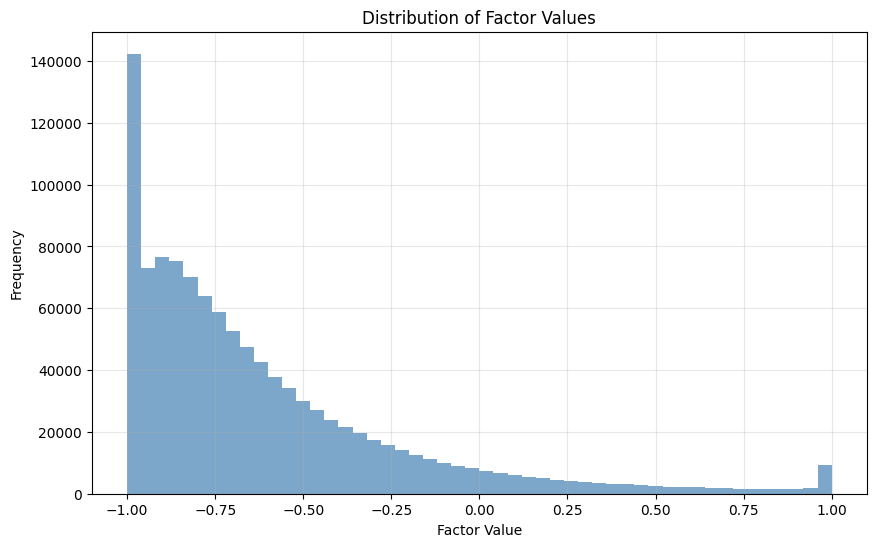

In [22]:
import matplotlib.pyplot as plt

# 绘制factor的分布图
plt.figure(figsize=(10, 6))
plt.hist(position_data['position'].to_numpy(), bins=50, color='steelblue', alpha=0.7)
plt.title('Distribution of Factor Values')
plt.xlabel('Factor Value')
plt.ylabel('Frequency')
plt.grid(alpha=0.3)
plt.show()

In [23]:
# position 当作当前 bar 收盘后持有到下一根 bar 的仓位，label1 是下一根收益。
position_eval = position_data.with_columns([
    (pl.col(POSITION_COL) * pl.col("label1")).alias("gross_margin_return"),
    pl.col(POSITION_COL).diff().abs().over("udl").fill_null(0.0).alias("position_change"),
])

position_eval = position_eval.with_columns([
    (pl.col("position_change") * FEE_PER_TURNOVER).alias("fee"),
    (pl.col("gross_margin_return") - pl.col("position_change") * FEE_PER_TURNOVER).alias("margin_return"),
])

position_eval = position_eval.with_columns([
    pl.col("gross_margin_return").cum_sum().over("udl").alias("cumulative_gross_return"),
    pl.col("margin_return").cum_sum().over("udl").alias("cumulative_return"),
    pl.col("fee").cum_sum().over("udl").alias("cumulative_fee"),
    pl.col("position_change").cum_sum().over("udl").alias("cumulative_turnover"),
])

final_stats = position_eval.group_by("udl").agg([
    pl.col("cumulative_gross_return").last().alias("gross_ret"),
    pl.col("cumulative_fee").last().alias("fee"),
    pl.col("cumulative_return").last().alias("ret"),
    pl.col("cumulative_turnover").last().alias("turnover"),
    pl.col("samp_ts").dt.date().n_unique().alias("n_days"),
])

final_stats = final_stats.with_columns([
    (pl.col("ret") / pl.max_horizontal(pl.col("turnover"), pl.lit(EPS)) * 10000).alias("ret_per_turnover_x10000"),
    (pl.col("turnover") / pl.col("n_days")).alias("daily_turnover"),
    (pl.col("turnover") / pl.col("n_days") * 365).alias("annual_turnover"),
])

summary_stats = final_stats.select([
    pl.col("gross_ret").mean().alias("avg_gross_ret"),
    pl.col("fee").mean().alias("avg_fee"),
    pl.col("ret").mean().alias("avg_ret"),
    pl.col("turnover").mean().alias("avg_total_turnover"),
    pl.col("daily_turnover").mean().alias("avg_daily_turnover"),
    pl.col("annual_turnover").mean().alias("avg_annual_turnover"),
    pl.col("ret_per_turnover_x10000").mean().alias("avg_ret_per_turnover_x10000"),
    pl.len().alias("n_udl"),
])

print(f"手续费: 每单位换手 {FEE_PER_TURNOVER:.4%}")
print(summary_stats)
final_stats.sort("ret_per_turnover_x10000", descending=True)


手续费: 每单位换手 0.0500%
shape: (1, 8)
┌─────────────┬──────────┬──────────┬─────────────┬─────────────┬─────────────┬────────────┬───────┐
│ avg_gross_r ┆ avg_fee  ┆ avg_ret  ┆ avg_total_t ┆ avg_daily_t ┆ avg_annual_ ┆ avg_ret_pe ┆ n_udl │
│ et          ┆ ---      ┆ ---      ┆ urnover     ┆ urnover     ┆ turnover    ┆ r_turnover ┆ ---   │
│ ---         ┆ f64      ┆ f64      ┆ ---         ┆ ---         ┆ ---         ┆ _x10000    ┆ u32   │
│ f64         ┆          ┆          ┆ f64         ┆ f64         ┆ f64         ┆ ---        ┆       │
│             ┆          ┆          ┆             ┆             ┆             ┆ f64        ┆       │
╞═════════════╪══════════╪══════════╪═════════════╪═════════════╪═════════════╪════════════╪═══════╡
│ 0.410998    ┆ 0.200892 ┆ 0.210107 ┆ 401.783745  ┆ 1.384467    ┆ 505.330616  ┆ 11.430989  ┆ 39    │
└─────────────┴──────────┴──────────┴─────────────┴─────────────┴─────────────┴────────────┴───────┘


udl,gross_ret,fee,ret,turnover,n_days,ret_per_turnover_x10000,daily_turnover,annual_turnover
str,f64,f64,f64,f64,u32,f64,f64,f64
"""NEIROUSDT""",1.228602,0.022536,1.206066,45.072934,291,267.580915,0.15489,56.534779
"""PUMPUSDT""",1.741879,0.185984,1.555895,371.967855,261,41.828754,1.425164,520.184931
"""WLDUSDT""",1.176213,0.19331,0.982903,386.619649,291,25.422993,1.32859,484.935299
"""MOODENGUSDT""",1.063706,0.206694,0.857012,413.387059,291,20.731472,1.420574,518.509541
"""1000BONKUSDT""",0.978556,0.203609,0.774946,407.218807,291,19.030219,1.399377,510.77273
…,…,…,…,…,…,…,…,…
"""XRPUSDT""",-0.025774,0.211801,-0.237575,423.602096,291,-5.608446,1.455677,531.322217
"""OPUSDT""",-0.033532,0.219771,-0.253304,439.542696,291,-5.762892,1.510456,551.31644
"""GALAUSDT""",-0.042984,0.223935,-0.266919,447.869715,291,-5.959739,1.539071,561.760983


In [24]:
print("平均单期换手:")
print(position_eval.select(pl.col("position_change").mean().alias("avg_bar_turnover")))

print("仓位分布:")
position_eval.select(POSITION_COL).describe()

平均单期换手:
shape: (1, 1)
┌──────────────────┐
│ avg_bar_turnover │
│ ---              │
│ f64              │
╞══════════════════╡
│ 0.014488         │
└──────────────────┘
仓位分布:


statistic,position
str,f64
"""count""",1.081536e6
"""null_count""",0.0
"""mean""",-0.613732
"""std""",0.394687
"""min""",-1.0
"""25%""",-0.891166
"""50%""",-0.73375
"""75%""",-0.47108
"""max""",1.0


In [25]:
# 第一步：计算扣费后的单期边际收益
# 手续费按每单位换手万五扣除。
data = position_data.with_columns([
    (pl.col("position") * pl.col("label1").over("udl")).alias("gross_margin_return"),
    pl.col("position").diff().abs().over("udl").fill_null(0.0).alias("position_change"),
])

data = data.with_columns([
    (pl.col("position_change") * FEE_PER_TURNOVER).alias("fee"),
    (pl.col("gross_margin_return") - pl.col("position_change") * FEE_PER_TURNOVER).alias("margin_return"),
])

data = data.fill_null(0)

# 第二步：计算累积边际收益
# cumulative_return 为扣费后收益，cumulative_gross_return 为扣费前收益。
data = data.with_columns([
    pl.col("gross_margin_return").cum_sum().over("udl").alias("cumulative_gross_return"),
    pl.col("margin_return").cum_sum().over("udl").alias("cumulative_return"),
    pl.col("fee").cum_sum().over("udl").alias("cumulative_fee"),
    pl.col("position_change").cum_sum().over("udl").alias("cumulative_turnover"),
])

# 获取每个品种最后一行的数据（相当于您代码中的last()）
final_stats = data.group_by("udl").agg(
    pl.col("cumulative_gross_return").last().alias("gross_ret"),
    pl.col("cumulative_fee").last().alias("fee"),
    pl.col("cumulative_return").last().alias("ret"),
    pl.col("cumulative_turnover").last().alias("abs_diff"),
)

# 计算扣费后的 ret/abs_diff（相当于您代码中的ret/abs_diff）
final_stats = final_stats.filter(pl.col("abs_diff") != 0)
final_stats = final_stats.with_columns(
    (pl.col("ret") / pl.col("abs_diff") * 10000).alias("ret_per_turnover")
)

# 按扣费后 ret 降序排序
sorted_stats = final_stats.sort("ret", descending=True)

# 计算扣费后 ret/abs_diff 的平均值
avg_ret_per_turnover = final_stats.select(pl.mean("ret_per_turnover")).item()

# 输出结果
print(f"手续费: 每单位换手 {FEE_PER_TURNOVER:.4%}")
print(f"扣费后平均每单位换手收益率（×10000）: {avg_ret_per_turnover}")

# 返回排序后的结果
sorted_stats.write_csv('sorted_stats_test.csv')
sorted_stats


手续费: 每单位换手 0.0500%
扣费后平均每单位换手收益率（×10000）: 11.731804471690419


udl,gross_ret,fee,ret,abs_diff,ret_per_turnover
str,f64,f64,f64,f64,f64
"""PUMPUSDT""",1.741879,0.185984,1.555895,371.967855,41.828754
"""NEIROUSDT""",1.228602,0.022536,1.206066,45.072934,267.580915
"""WLDUSDT""",1.176213,0.19331,0.982903,386.619649,25.422993
"""MOODENGUSDT""",1.063706,0.206694,0.857012,413.387059,20.731472
"""1000BONKUSDT""",0.978556,0.203609,0.774946,407.218807,19.030219
…,…,…,…,…,…
"""OPUSDT""",-0.033532,0.219771,-0.253304,439.542696,-5.762892
"""GALAUSDT""",-0.042984,0.223935,-0.266919,447.869715,-5.959739
"""HYPEUSDT""",-0.015507,0.257555,-0.273062,515.109349,-5.301043


In [26]:
# 每个品种每天的 margin_return 之和（扣费后当日实际收益）

data = data.with_columns(
    pl.col("samp_ts").dt.date().alias("d")
)
data = data.with_columns(
    pl.col("d").alias("day")
)
data_perday = data.group_by(["day", "udl"]).agg([
    pl.col("gross_margin_return").sum().alias("gross_daily_ret"),
    pl.col("fee").sum().alias("daily_fee"),
    pl.col("margin_return").sum().alias("daily_ret"),
])

# 按 day 聚合：横截面等权平均，avg_ret 为扣费后平均收益。
data_perday = data_perday.group_by("day").agg([
    pl.col("gross_daily_ret").mean().alias("avg_gross_ret"),
    pl.col("daily_fee").mean().alias("avg_fee"),
    pl.col("daily_ret").mean().alias("avg_ret"),
])

data_perday = data_perday.sort("day")
data_perday


day,avg_gross_ret,avg_fee,avg_ret
date,f64,f64,f64
2025-06-15,-0.00076,0.000185,-0.000945
2025-06-16,-0.022802,0.000509,-0.023311
2025-06-17,0.0439,0.001573,0.042327
2025-06-18,0.013762,0.000491,0.013271
2025-06-19,0.000086,0.000465,-0.000379
…,…,…,…
2026-03-28,-0.009413,0.000469,-0.009882
2026-03-29,0.026331,0.000424,0.025907
2026-03-30,-0.013561,0.000695,-0.014256


In [27]:
# 累计收益曲线
curve = data_perday.with_columns(
    pl.col("avg_ret").cum_sum().alias("cum_avg_ret")
)
curve

day,avg_gross_ret,avg_fee,avg_ret,cum_avg_ret
date,f64,f64,f64,f64
2025-06-15,-0.00076,0.000185,-0.000945,-0.000945
2025-06-16,-0.022802,0.000509,-0.023311,-0.024256
2025-06-17,0.0439,0.001573,0.042327,0.018071
2025-06-18,0.013762,0.000491,0.013271,0.031343
2025-06-19,0.000086,0.000465,-0.000379,0.030964
…,…,…,…,…
2026-03-28,-0.009413,0.000469,-0.009882,0.190325
2026-03-29,0.026331,0.000424,0.025907,0.216232
2026-03-30,-0.013561,0.000695,-0.014256,0.201976


In [ ]:
import matplotlib.pyplot as plt

curve_pd = curve.sort("day").to_pandas()
# curve_pd["date"] = pd.to_datetime(curve_pd["day"].astype(str), format="%Y%m%d")
curve_pd['date'] = curve_pd['day']
curve_pd = curve_pd.set_index("date")

fig, ax = plt.subplots(figsize=(16, 6))
curve_pd["cum_avg_ret"].plot(ax=ax, color="darkorange", linewidth=1)
ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax.set_xlabel("date")
ax.set_ylabel("cum_avg_ret")
ax.set_title("Cumulative Average Return After Fee")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
